In [1]:
from matplotlib import pyplot as plt
import numpy as np
import random
import pandas as pd
import seaborn as sns
from scipy.stats import pearsonr
import os
from collections import Counter
import h5py
from utils.metrics import *
from collections import defaultdict

sns.set(style="whitegrid")

In [2]:
method = "videopose"
base_dir = "./results"
splits = list(range(7))
task = 'class'

all_preds = []
all_actuals = []

for split in splits:
    file_path = os.path.join(base_dir, task, method, f"{method}_smooth{split}.npy")
    print(f"Loading data from: {file_path}")
    data = np.load(file_path, allow_pickle=True)
    pred, actual = get_data(data, task)

    all_preds.append(pred)
    all_actuals.append(actual)

Loading data from: ./results\class\videopose\videopose_smooth0.npy
Loading data from: ./results\class\videopose\videopose_smooth1.npy
Loading data from: ./results\class\videopose\videopose_smooth2.npy
Loading data from: ./results\class\videopose\videopose_smooth3.npy
Loading data from: ./results\class\videopose\videopose_smooth4.npy
Loading data from: ./results\class\videopose\videopose_smooth5.npy
Loading data from: ./results\class\videopose\videopose_smooth6.npy


In [7]:
all_labels_flat = np.concatenate(all_actuals)

unique_labels = np.unique(all_labels_flat)
print("Unique labels:", unique_labels)
label_counts_per_subject = []

for subject_labels in all_actuals:
    counts_dict = {int(label): 0 for label in unique_labels}
    
    unique, counts = np.unique(subject_labels, return_counts=True)
    for u, c in zip(unique, counts):
        counts_dict[int(u)] = int(c)
    
    label_counts_per_subject.append(counts_dict)

# Convert to array (subjects × labels)
labels_sorted = sorted(unique_labels)
counts_array = np.array([[subj[label] for label in labels_sorted] 
                         for subj in label_counts_per_subject])

# Compute mean and std
means = counts_array.mean(axis=0)
stds = counts_array.std(axis=0)

# Print nicely
for label, m, s in zip(labels_sorted, means, stds):
    print(f"Label {label}: {m:.1f} ± {s:.1f} frames")

Unique labels: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14]
Label 0: 25747.4 ± 6072.9 frames
Label 1: 10994.6 ± 1555.6 frames
Label 2: 12277.7 ± 2379.4 frames
Label 3: 10347.6 ± 1126.1 frames
Label 4: 11175.9 ± 911.4 frames
Label 5: 8578.9 ± 3711.6 frames
Label 6: 8774.1 ± 3785.3 frames
Label 7: 10536.4 ± 937.8 frames
Label 8: 10492.6 ± 806.5 frames
Label 9: 9849.7 ± 3370.3 frames
Label 10: 9549.4 ± 3250.2 frames
Label 11: 5435.0 ± 611.5 frames
Label 12: 5090.1 ± 554.7 frames
Label 13: 5636.1 ± 457.0 frames
Label 14: 5471.6 ± 787.1 frames


In [8]:
def map_to_complete_exercises(all_actuals):
    """
    Maps detailed frame-wise exercise labels to higher-level complete exercise categories.

    Parameters:
    - all_actuals: dict of {fold_idx: np.ndarray of frame-wise detailed labels}

    Returns:
    - mapped_actuals: dict of {fold_idx: np.ndarray of mapped complete exercise labels}
    """

    # Mapping from original label to complete exercise label ID
    label_mapping = {
        0: 0,  # Random movements
        1: 1,  # Sit-to-stand
        2: 1,
        3: 2,  # Bending forward/backward on chair
        4: 2,
        5: 3,  # Moving a weight between armrests
        6: 3,
        7: 4,  # Lateral leg movement
        8: 4,
        9: 5,  # Picking up a box
        10: 5,
        11: 6,  # Touching a cup with foot
        12: 6,
        13: 6,
        14: 6
    }

    mapped_actuals = []
    for labels in all_actuals:
        mapped_labels = np.array([label_mapping.get(label, -1) for label in labels])
        mapped_actuals.append(mapped_labels)

    return mapped_actuals

In [ ]:
mapped_labels = map_to_complete_exercises(all_actuals)
label_counts = []
for fold_labels in mapped_labels:
    counts = np.bincount(fold_labels, minlength=7)
    label_counts.append(counts)

label_counts = np.array(label_counts)  # shape (folds, labels)

# Prepare data for seaborn boxplot
plot_data = []
for label in range(label_counts.shape[1]):
    for fold_idx in range(label_counts.shape[0]):
        plot_data.append({
            "Exercise Label": f"Exercise {label}",
            "Count": label_counts[fold_idx, label],
            "Fold": f"Fold {fold_idx + 1}"
        })

df = pd.DataFrame(plot_data)


In [8]:
def get_total_seg_dur_per_fold(pred, actual, sampling_rate=30):
    def compute_seg_dur(labels):
        segment_durations = {i: 0 for i in range(15)}  # Assuming 15 possible segments
        current_segment = None
        current_duration = 0

        for label in labels:
            if label != current_segment:
                if current_segment is not None:
                    segment_durations[current_segment] += current_duration
                current_segment = label
                current_duration = 1
            else:
                current_duration += 1

        # Capture final segment
        if current_segment is not None:
            segment_durations[current_segment] += current_duration

        return segment_durations

    segment_durations_pred = []
    segment_durations_actual = []

    for fold_pred, fold_actual in zip(pred, actual):
        pred_dur = compute_seg_dur(fold_pred)
        actual_dur = compute_seg_dur(fold_actual)

        # Convert from frames to minutes
        pred_dur_min = {seg: round(dur / (sampling_rate * 60), 2) for seg, dur in pred_dur.items()}
        actual_dur_min = {seg: round(dur / (sampling_rate * 60), 2) for seg, dur in actual_dur.items()}

        segment_durations_pred.append(pred_dur_min)
        segment_durations_actual.append(actual_dur_min)

    return segment_durations_pred, segment_durations_actual

from collections import Counter

def get_segment_repetitions(labels_per_fold, window_size=30):
    """
    Counts the number of times an exercise segment is repeated across multiple CV folds,
    incorporating a smoothing mechanism based on majority voting.

    Parameters:
        labels_per_fold (list of lists): A list where each sublist contains frame-by-frame labels for a CV fold.
        window_size (int): The size of the window for majority voting. Default is 30 frames.

    Returns:
        list of dict: A list of dictionaries, one for each fold, where keys are exercise labels and values are the count of repetitions.
    """
    repetitions_per_fold = []

    for labels in labels_per_fold:
        segment_repetitions = {}
        current_segment = None

        for t in range(len(labels) - window_size + 1):  # Slide through the sequence for this fold
            # Get the majority label in the current window
            window = labels[t:t + window_size]
            majority_label = Counter(window).most_common(1)[0][0]

            # Only count a new repetition if the majority label changes
            if majority_label != current_segment:
                current_segment = majority_label
                if current_segment in segment_repetitions:
                    segment_repetitions[current_segment] += 1
                else:
                    segment_repetitions[current_segment] = 1

        repetitions_per_fold.append(segment_repetitions)

    return repetitions_per_fold

In [ ]:
# Exercise duration 
segment_durations_pred, segment_durations_actual = get_total_seg_dur_per_fold(
    all_preds, all_actuals, sampling_rate=30
)

reps_pred = get_segment_repetitions(all_preds, window_size=30)
reps_actual = get_segment_repetitions(all_actuals, window_size=30)

per_segment_pred_dur = defaultdict(list)
per_segment_actual_dur = defaultdict(list)
per_segment_pred_reps = defaultdict(list)
per_segment_actual_reps = defaultdict(list)

for fold_pred_dur, fold_actual_dur, fold_pred_reps, fold_actual_reps in zip(
    segment_durations_pred, segment_durations_actual, reps_pred, reps_actual
):
    for seg in fold_actual_dur.keys():
        if seg == 0:
            continue
        per_segment_actual_dur[seg].append(fold_actual_dur.get(seg, 0))
        per_segment_pred_dur[seg].append(fold_pred_dur.get(seg, 0))
        per_segment_actual_reps[seg].append(fold_actual_reps.get(seg, 0))
        per_segment_pred_reps[seg].append(fold_pred_reps.get(seg, 0))

segment_ids = sorted(set(per_segment_actual_dur.keys()))

mean_actual_dur = [np.mean(per_segment_actual_dur[seg]) for seg in segment_ids]
mean_pred_dur = [np.mean(per_segment_pred_dur[seg]) for seg in segment_ids]
mean_actual_reps = [np.mean(per_segment_actual_reps[seg]) for seg in segment_ids]
mean_pred_reps = [np.mean(per_segment_pred_reps[seg]) for seg in segment_ids]

corr_dur, _ = pearsonr(mean_actual_dur, mean_pred_dur)
corr_reps, _ = pearsonr(mean_actual_reps, mean_pred_reps)

In [11]:
from scipy.stats import norm

def pearson_confidence_interval(r, n, alpha=0.05):
    if n <= 3:
        return None, None  # Too few samples for meaningful CI

    z = np.arctanh(r)
    se = 1 / np.sqrt(n - 3)
    z_crit = norm.ppf(1 - alpha / 2)
    
    z_ci_lower = z - z_crit * se
    z_ci_upper = z + z_crit * se
    
    return np.tanh(z_ci_lower), np.tanh(z_ci_upper)

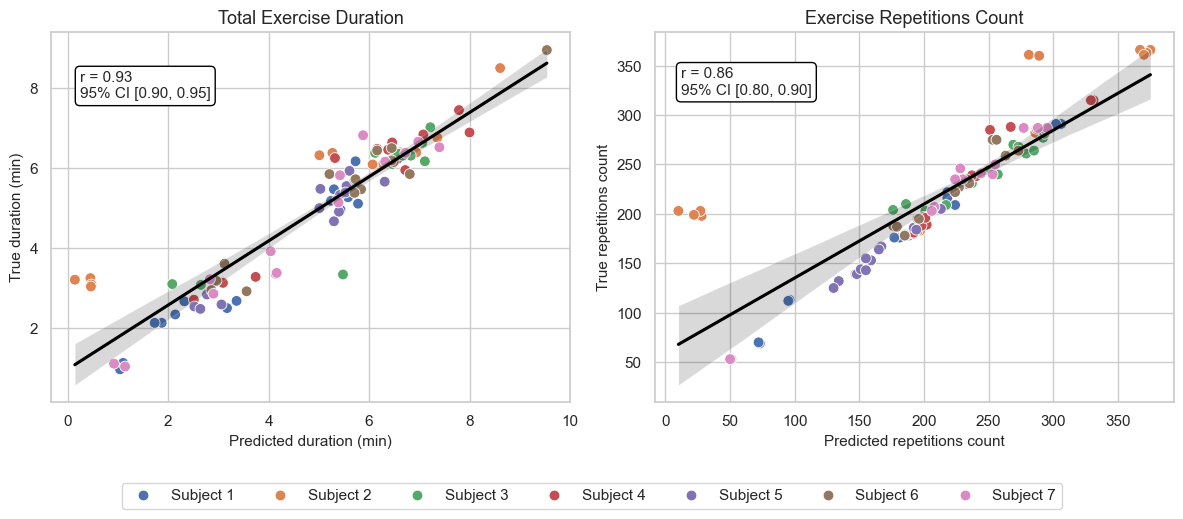

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr

# Build DataFrames
dur_rows = []
rep_rows = []

for fold_idx, (dur_p, dur_a, rep_p, rep_a) in enumerate(zip(segment_durations_pred, segment_durations_actual, reps_pred, reps_actual)):
    for label in dur_p:
        if label in dur_a and label != 0:
            dur_rows.append({
                "Predicted": dur_p[label],
                "Actual": dur_a[label],
                "Subject": f"Subject {fold_idx + 1}"
            })
    for label in rep_p:
        if label in rep_a and label != 0:
            rep_rows.append({
                "Predicted": rep_p[label],
                "Actual": rep_a[label],
                "Subject": f"Subject {fold_idx + 1}"
            })

df_dur = pd.DataFrame(dur_rows)
df_rep = pd.DataFrame(rep_rows)

# Duration
corr_dur, _ = pearsonr(df_dur["Predicted"], df_dur["Actual"])
ci_dur_low, ci_dur_high = pearson_confidence_interval(corr_dur, len(df_dur))

# Repetitions
corr_rep, _ = pearsonr(df_rep["Predicted"], df_rep["Actual"])
ci_rep_low, ci_rep_high = pearson_confidence_interval(corr_rep, len(df_rep))

# Plot
sns.set(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Duration plot
sns.scatterplot(data=df_dur, x="Predicted", y="Actual", hue="Subject", ax=axes[0], s=60)
sns.regplot(data=df_dur, x="Predicted", y="Actual", ax=axes[0], ci=95, scatter=False, color="black")
axes[0].set_title("Total Exercise Duration", fontsize=13)
axes[0].set_xlabel("Predicted duration (min)", fontsize=11)
axes[0].set_ylabel("True duration (min)", fontsize=11)
axes[0].text(
    min(df_dur["Predicted"]) + 0.1, max(df_dur["Actual"]) - 1.2,
    f"r = {corr_dur:.2f}\n95% CI [{ci_dur_low:.2f}, {ci_dur_high:.2f}]",
    fontsize=11,
    bbox=dict(facecolor="white", edgecolor="black", boxstyle="round,pad=0.3")
)


# Repetitions plot
sns.scatterplot(data=df_rep, x="Predicted", y="Actual", hue="Subject", ax=axes[1], s=60)
sns.regplot(data=df_rep, x="Predicted", y="Actual", ax=axes[1], ci=95, scatter=False, color="black")
axes[1].set_title("Exercise Repetitions Count", fontsize=13)
axes[1].set_xlabel("Predicted repetitions count", fontsize=11)
axes[1].set_ylabel("True repetitions count", fontsize=11)
axes[1].text(
    min(df_rep["Predicted"]) + 2, max(df_rep["Actual"]) - 45,
    f"r = {corr_rep:.2f}\n95% CI [{ci_rep_low:.2f}, {ci_rep_high:.2f}]",
    fontsize=11,
    bbox=dict(facecolor="white", edgecolor="black", boxstyle="round,pad=0.3")
)

axes[0].legend_.remove()
axes[1].legend_.remove()
fig.legend(handles=axes[0].get_legend_handles_labels()[0], labels=axes[0].get_legend_handles_labels()[1], loc='lower center', ncol=len(df_dur["Subject"].unique()), bbox_to_anchor=(0.5, -0.05))
plt.tight_layout(rect=[0, 0.05, 1, 1])
# plt.savefig("results/figures/count-dur.svg", format="svg")
plt.show()


In [10]:
import numpy as np
import pandas as pd
from collections import Counter

sampling_rate = 30
num_classes = 15
window_size = 30

# --------------------------------------------
# 1. Frames per subject per label
# --------------------------------------------
frames_per_subject = []

for subject_labels in all_actuals:
    counts = {i: 0 for i in range(num_classes)}
    unique, cnts = np.unique(subject_labels, return_counts=True)
    for u, c in zip(unique, cnts):
        counts[int(u)] = int(c)
    frames_per_subject.append(counts)

# Convert to array [subjects x labels]
frames_array = np.array([
    [subj[label] for label in range(num_classes)]
    for subj in frames_per_subject
])

# Mean frames across subjects
mean_frames_per_label = frames_array.mean(axis=0)


# --------------------------------------------
# 2. Total duration across all subjects
# --------------------------------------------
total_frames_per_label = frames_array.sum(axis=0)

total_duration_min_per_label = total_frames_per_label / (sampling_rate * 60)


# --------------------------------------------
# 3. Total repetitions across all subjects
# --------------------------------------------
def get_segment_repetitions_single(labels, window_size=30, num_classes=15):
    segment_repetitions = {i: 0 for i in range(num_classes)}
    current_segment = None

    for t in range(len(labels) - window_size + 1):
        window = labels[t:t + window_size]
        majority_label = Counter(window).most_common(1)[0][0]
        majority_label = int(majority_label)

        if majority_label != current_segment:
            current_segment = majority_label
            segment_repetitions[current_segment] += 1

    return segment_repetitions

total_repetitions_per_label = {i: 0 for i in range(num_classes)}

for subject_labels in all_actuals:
    reps = get_segment_repetitions_single(subject_labels, window_size, num_classes)
    for label in range(num_classes):
        total_repetitions_per_label[label] += reps[label]


# --------------------------------------------
# 4. Final table
# --------------------------------------------
summary_df = pd.DataFrame({
    "Exercise": list(range(num_classes)),
    "Mean #frames": np.round(mean_frames_per_label, 1),
    "Total duration (min)": np.round(total_duration_min_per_label, 2),
    "# repetitions": [int(total_repetitions_per_label[label]) for label in range(num_classes)],
})

print(summary_df)

    Exercise  Mean #frames  Total duration (min)  # repetitions
0          0       25747.4                100.13            752
1          1       10994.6                 42.76           1377
2          2       12277.7                 47.75           1372
3          3       10347.6                 40.24           1900
4          4       11175.9                 43.46           1903
5          5        8578.9                 33.36           1475
6          6        8774.1                 34.12           1491
7          7       10536.4                 40.98           1565
8          8       10492.6                 40.80           1576
9          9        9849.7                 38.30           1782
10        10        9549.4                 37.14           1775
11        11        5435.0                 21.14           1327
12        12        5090.1                 19.80           1328
13        13        5636.1                 21.92           1352
14        14        5471.6              

In [19]:
def get_label_sequences(labels, target_label):
    """
    Finds the start and end indices of sequences where the label equals the target_label.

    Parameters:
        labels (list or array): List or array of labels.
        target_label (int): The target label to identify sequences for.

    Returns:
        list of tuples: Each tuple contains (start_index, end_index) for a sequence.
    """
    sequences = []
    start = None

    for i, label in enumerate(labels):
        if label == target_label and start is None:  # Start of a new sequence
            start = i
        elif label != target_label and start is not None:  # End of a sequence
            sequences.append((start, i - 1))
            start = None

    # Handle the case where a sequence ends at the last label
    if start is not None:
        sequences.append((start, len(labels) - 1))

    return sequences

In [18]:
task = 'reg'
joint_mask = np.array([1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1], dtype=np.float32)
joint_indices = np.where(joint_mask == 1)[0]
all_preds_reg = {}
all_actuals_reg = {}

for split in splits:
    file_path = os.path.join(base_dir, task, method, f"{method}_split{split}.npy")
    print(f"Loading data from: {file_path}")
    data = np.load(file_path, allow_pickle=True)
    pred, actual = get_data(data, task)

    # Apply joint mask to filter only relevant joints
    pred_masked = pred[:, joint_indices, :]
    actual_masked = actual[:, joint_indices, :]

    all_preds_reg[split] = pred_masked
    all_actuals_reg[split] = actual_masked
    # if split ==0:
    #     break

Loading data from: /data/leuven/365/vsc36565/WZC/results/reg/videopose/videopose_split0.npy
Loading data from: /data/leuven/365/vsc36565/WZC/results/reg/videopose/videopose_split1.npy
Loading data from: /data/leuven/365/vsc36565/WZC/results/reg/videopose/videopose_split2.npy
Loading data from: /data/leuven/365/vsc36565/WZC/results/reg/videopose/videopose_split3.npy
Loading data from: /data/leuven/365/vsc36565/WZC/results/reg/videopose/videopose_split4.npy
Loading data from: /data/leuven/365/vsc36565/WZC/results/reg/videopose/videopose_split5.npy
Loading data from: /data/leuven/365/vsc36565/WZC/results/reg/videopose/videopose_split6.npy


In [11]:
sequences = get_label_sequences(all_actuals[0], target_label=2)
# Combine the fine grained exercises to the complete exercises 
mapped_sequences = get_label_sequences(mapped_labels[0], target_label=1)

In [21]:
mad_results_true = defaultdict(lambda: {
    'x': defaultdict(lambda: defaultdict(list)),
    'z': defaultdict(lambda: defaultdict(list)),
    'y': defaultdict(lambda: defaultdict(list))
})

mad_results_pred = defaultdict(lambda: {
    'x': defaultdict(lambda: defaultdict(list)),
    'z': defaultdict(lambda: defaultdict(list)),
    'y': defaultdict(lambda: defaultdict(list))
})

axis_map = {0: 'x', 1: 'z', 2: 'y'}
exercise_labels = range(15)  # Adjust if needed

# Determine joint_ids based on any fold
sample_split = next(iter(all_preds_reg))
joint_ids = range(all_preds_reg[sample_split].shape[1])  # shape: (samples, joints, 3)

for fold_idx in all_preds_reg.keys():
    pred_fold = all_preds_reg[fold_idx]  # (samples, joints, 3)
    true_fold = all_actuals_reg[fold_idx]  # (samples, joints, 3)
    # class_labels_fold = all_actuals[fold_idx]  # (samples,)
    class_labels_fold = all_actuals[fold_idx] # or mapped_labels if you want the complete exercises and not the sub-exercise actions
 
    for joint_id in joint_ids:
        for axis_idx in [0, 1, 2]:  # x, z, y
            axis_name = axis_map[axis_idx]

            joint_pred = pred_fold[:, joint_id, axis_idx]
            joint_true = true_fold[:, joint_id, axis_idx]

            for exercise_label in exercise_labels:
                sequences = get_label_sequences(class_labels_fold, target_label=exercise_label)

                for start, end in sequences:
                    true_seg = joint_true[start:end + 1]
                    pred_seg = joint_pred[start:end + 1]

                    if len(true_seg) > 0:
                        mad_true = np.mean(np.abs(true_seg - np.mean(true_seg)))
                        mad_results_true[fold_idx][axis_name][joint_id][exercise_label].append(mad_true)

                    if len(pred_seg) > 0:
                        mad_pred = np.mean(np.abs(pred_seg - np.mean(pred_seg)))
                        mad_results_pred[fold_idx][axis_name][joint_id][exercise_label].append(mad_pred)


In [33]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.stats import pearsonr

def plot_mad_rom_dual_correlation_heatmaps(
    mad_results_true_folds, mad_results_pred_folds,
    rom_results_true_folds, rom_results_pred_folds,
    selected_folds, exercise_labels
):
    axis = 'y'  # Only flexion/extension
    coord_title = "Flexion/Extension"
    joint_names = ['L5S1','L1T12','T1C7','Right Hip','Right Knee','Right Ankle','Left Hip','Left Knee','Left Ankle']
    num_joints = len(mad_results_true_folds[selected_folds[0]][axis].keys())

    # Function to compute correlation matrix for MAD or ROM
    def compute_corr_matrix(true_folds, pred_folds):
        corr_matrix = np.full((num_joints, len(exercise_labels)), np.nan)
        for joint in range(num_joints):
            for j, label in enumerate(exercise_labels):
                preds_all = []
                trues_all = []
                for fold in selected_folds:
                    preds_all.extend(pred_folds[fold][axis][joint][label])
                    trues_all.extend(true_folds[fold][axis][joint][label])
                if len(preds_all) > 1 and len(set(preds_all)) > 1 and len(set(trues_all)) > 1:
                    corr, _ = pearsonr(preds_all, trues_all)
                    corr_matrix[joint, j] = np.abs(corr)
        return corr_matrix

    # Compute correlation matrices
    mad_corr_matrix = compute_corr_matrix(mad_results_true_folds, mad_results_pred_folds)
    rom_corr_matrix = compute_corr_matrix(rom_results_true_folds, rom_results_pred_folds)

    # Determine color scale limits based on all values
    combined_values = np.concatenate([mad_corr_matrix[~np.isnan(mad_corr_matrix)], rom_corr_matrix[~np.isnan(rom_corr_matrix)]])
    vmin, vmax = combined_values.min(), combined_values.max()

    # Plot
    fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)
    cbar_ax = fig.add_axes([0.93, 0.3, 0.015, 0.4])

    for idx, (matrix, title) in enumerate(zip([mad_corr_matrix, rom_corr_matrix], ['Mean absolute deviation (MAD)', 'Range of motion (ROM)'])):
        sns.heatmap(
            matrix,
            annot=True,
            fmt=".1f",
            annot_kws={"fontsize": 12},
            xticklabels=exercise_labels,
            yticklabels=joint_names,
            cmap="coolwarm",
            center=0,
            vmin=vmin,
            vmax=vmax,
            cbar=idx == 0,
            cbar_ax=cbar_ax if idx == 0 else None,
            ax=axes[idx],
            cbar_kws={"label": "Correlation"}
        )
        axes[idx].set_title(f"{title}")
        axes[idx].set_xlabel("Sub-exercise action labels")
        # if idx == 0:
        #     axes[idx].set_ylabel("Joints")

    # fig.suptitle(
    #     "Correlation between estimated and actual exercise performance outcome for Flexion/Extension joint angle",
    #     fontsize=16,
    #     y=1.0
    # )

    plt.tight_layout(rect=[0, 0, 0.92, 1])
    plt.savefig("results/figures/mad_rom.svg", format="svg")
    plt.show()


In [ ]:
from collections import defaultdict
import numpy as np

# Store ROM per fold
rom_results_true = defaultdict(lambda: {'x': defaultdict(lambda: defaultdict(list)),
                                        'z': defaultdict(lambda: defaultdict(list)),
                                        'y': defaultdict(lambda: defaultdict(list))})

rom_results_pred = defaultdict(lambda: {'x': defaultdict(lambda: defaultdict(list)),
                                        'z': defaultdict(lambda: defaultdict(list)),
                                        'y': defaultdict(lambda: defaultdict(list))})

axis_map = {0: 'x', 1: 'z', 2: 'y'}
exercise_labels = range(15)  # Adjust if needed

# Determine joint_ids based on the masked joint size
sample_split = next(iter(all_preds_reg))  # any split
joint_ids = range(all_preds_reg[sample_split].shape[1])  # shape: (samples, joints, 3)

for fold_idx in all_preds_reg.keys():
    pred_fold = all_preds_reg[fold_idx]  # (samples, joints, 3)
    true_fold = all_actuals_reg[fold_idx]  # (samples, joints, 3)
    #class_labels_fold = mapped_labels[fold_idx]  # (samples,)
    class_labels_fold = all_actuals[fold_idx]

    for joint_id in joint_ids:
        for axis_idx in [0, 1, 2]:  # x, z, y
            axis_name = axis_map[axis_idx]

            joint_pred = pred_fold[:, joint_id, axis_idx]
            joint_true = true_fold[:, joint_id, axis_idx]

            for exercise_label in exercise_labels:
                sequences = get_label_sequences(class_labels_fold, target_label=exercise_label)

                for start, end in sequences:
                    true_seg = joint_true[start:end + 1]
                    pred_seg = joint_pred[start:end + 1]

                    rom_true = np.max(true_seg) - np.min(true_seg)
                    rom_results_true[fold_idx][axis_name][joint_id][exercise_label].append(rom_true)

                    rom_pred = np.max(pred_seg) - np.min(pred_seg)
                    rom_results_pred[fold_idx][axis_name][joint_id][exercise_label].append(rom_pred)


/tmp/ipykernel_1051469/2500035973.py:71: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.92, 1])


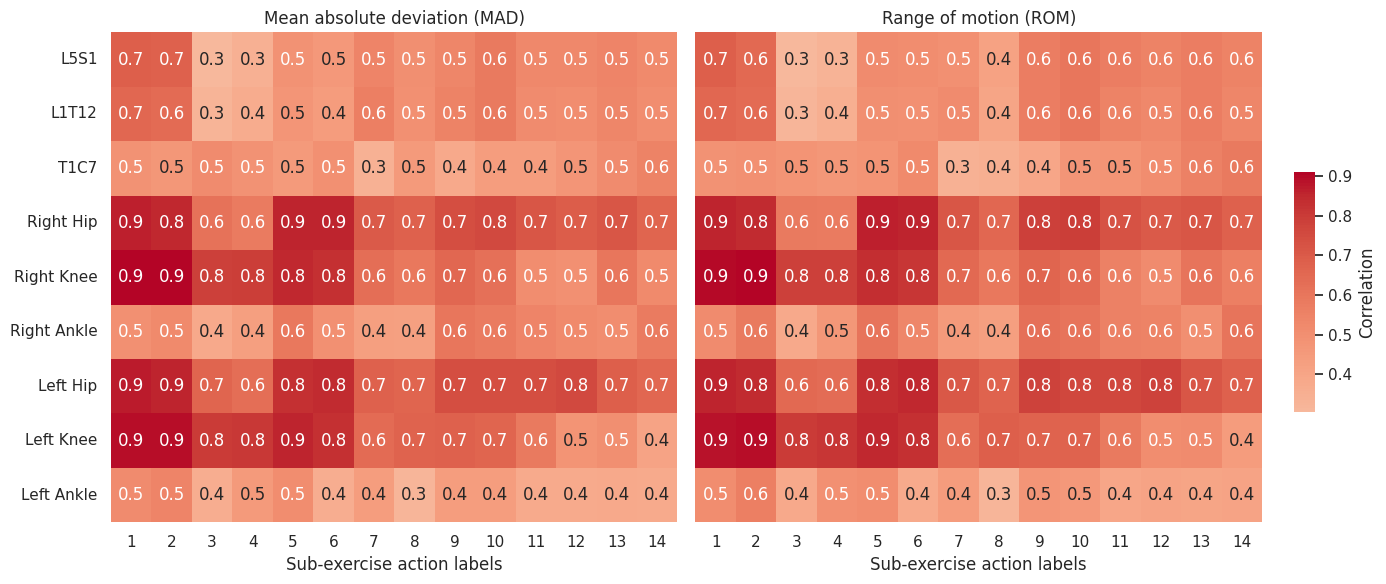

In [ ]:
selected_folds = [0, 1, 2, 3, 4, 5, 6]
plot_mad_rom_dual_correlation_heatmaps(
    mad_results_true, mad_results_pred,
    rom_results_true, rom_results_pred,
    selected_folds, [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14]
)

In [ ]:
import matplotlib.pyplot as plt

def plot_mad_rom_segments_by_exercise(
    fold_idx,
    segment_range,
    exercise_label=1,
    joint_names={"left_hip": 0, "right_hip": 1},
    axis='z'
):
    """
    Plot MAD and ROM (actual vs predicted) for both hips over multiple segments of a given exercise.

    Parameters:
    - fold_idx (int): Fold number.
    - segment_range (tuple): (start_idx, end_idx) of segments (inclusive-exclusive).
    - exercise_label (int): Exercise label (default 1 for sit-to-stand).
    - joint_names (dict): Mapping of joint names to masked joint indices.
    - axis (str): Axis to use: 'x', 'y', or 'z'.
    """
    assert axis in ['x', 'y', 'z'], "Axis must be one of 'x', 'y', or 'z'."

    axis_idx = {'x': 0, 'z': 1, 'y': 2}[axis]

    # Data
    class_labels_fold = all_actuals[fold_idx]
    pred_fold = all_preds_reg[fold_idx]
    true_fold = all_actuals_reg[fold_idx]

    # Get sequences for the selected exercise
    sequences = get_label_sequences(class_labels_fold, target_label=exercise_label)
    selected_sequences = sequences[segment_range[0]:segment_range[1]]

    fig, axs = plt.subplots(2, 1, figsize=(10, 8), sharex=True)
    axs[0].set_title(f"MAD for Hip Joints - Fold {fold_idx}")
    axs[1].set_title(f"ROM for Hip Joints - Fold {fold_idx}")

    # Color map per joint
    color_map = {
        "left_hip": "tab:blue",
        "right_hip": "tab:orange"
    }

    for joint_label, joint_id in joint_names.items():
        color = color_map[joint_label]
        mad_true_list, mad_pred_list = [], []
        rom_true_list, rom_pred_list = [], []

        joint_pred = pred_fold[:, joint_id, axis_idx]
        joint_true = true_fold[:, joint_id, axis_idx]

        for start, end in selected_sequences:
            true_seg = joint_true[start:end + 1]
            pred_seg = joint_pred[start:end + 1]

            mad_true = np.mean(np.abs(true_seg - np.mean(true_seg)))
            mad_pred = np.mean(np.abs(pred_seg - np.mean(pred_seg)))
            mad_true_list.append(mad_true)
            mad_pred_list.append(mad_pred)

            rom_true = np.max(true_seg) - np.min(true_seg)
            rom_pred = np.max(pred_seg) - np.min(pred_seg)
            rom_true_list.append(rom_true)
            rom_pred_list.append(rom_pred)

        segment_indices = list(range(segment_range[0], segment_range[1]))

        # Plot MAD
        axs[0].plot(segment_indices, mad_true_list, label=f"{joint_label} - Actual",
                    color=color, linestyle='-')
        axs[0].plot(segment_indices, mad_pred_list, label=f"{joint_label} - Predicted",
                    color=color, linestyle='--')

        # Plot ROM
        axs[1].plot(segment_indices, rom_true_list, label=f"{joint_label} - Actual",
                    color=color, linestyle='-')
        axs[1].plot(segment_indices, rom_pred_list, label=f"{joint_label} - Predicted",
                    color=color, linestyle='--')

    axs[0].set_ylabel("MAD")
    axs[1].set_ylabel("ROM")
    axs[1].set_xlabel("Segment Index")
    axs[0].grid(True)
    axs[1].grid(True)
    axs[0].legend()
    axs[1].legend()
    plt.tight_layout()
    plt.show()


In [105]:
def compute_mad_zscores_with_interpretation(
    fold_idx,
    segment_range,
    exercise_label=1,
    joint_names={"left_hip": 0, "right_hip": 1},
    axis='z'
):
    """
    Computes MAD z-scores (actual and predicted) for selected segments and prints interpretations.

    Returns:
        dict: {joint_name: list of (segment_idx, mad_actual, z_actual, mad_pred, z_pred, interpretation)}
    """
    axis_idx = {'x': 0, 'z': 1, 'y': 2}[axis]

    class_labels_fold = all_actuals[fold_idx]
    pred_fold = all_preds_reg[fold_idx]
    true_fold = all_actuals_reg[fold_idx]

    sequences = get_label_sequences(class_labels_fold, target_label=exercise_label)
    selected_sequences = sequences[segment_range[0]:segment_range[1]]
    segment_indices = list(range(segment_range[0], segment_range[1]))

    results = {}

    for joint_label, joint_id in joint_names.items():
        joint_true = true_fold[:, joint_id, axis_idx]
        joint_pred = pred_fold[:, joint_id, axis_idx]

        # --- Compute MADs over ALL segments for reference ---
        all_mads_actual = []
        all_mads_pred = []

        for start, end in sequences:
            seg_true = joint_true[start:end + 1]
            seg_pred = joint_pred[start:end + 1]

            mad_true = np.mean(np.abs(seg_true - np.mean(seg_true)))
            mad_pred = np.mean(np.abs(seg_pred - np.mean(seg_pred)))

            all_mads_actual.append(mad_true)
            all_mads_pred.append(mad_pred)

        mean_actual, std_actual = np.mean(all_mads_actual), np.std(all_mads_actual)
        mean_pred, std_pred = np.mean(all_mads_pred), np.std(all_mads_pred)

        # --- Z-scores for selected segments ---
        joint_results = []
        for idx, (start, end) in zip(segment_indices, selected_sequences):
            seg_true = joint_true[start:end + 1]
            seg_pred = joint_pred[start:end + 1]

            mad_true = np.mean(np.abs(seg_true - np.mean(seg_true)))
            mad_pred = np.mean(np.abs(seg_pred - np.mean(seg_pred)))

            z_true = (mad_true - mean_actual) / std_actual if std_actual > 0 else 0.0
            z_pred = (mad_pred - mean_pred) / std_pred if std_pred > 0 else 0.0

            interpretation = interpret_zscore(z_true)

            joint_results.append((idx, mad_true, z_true, mad_pred, z_pred, interpretation))

        results[joint_label] = joint_results

    # Print output
    for joint_label, joint_data in results.items():
        print(f"\n🦿 Z-score analysis for {joint_label} (Fold {fold_idx}):")
        for idx, mad_true, z_true, mad_pred, z_pred, interp in joint_data:
            print(f"  Segment {idx}:")
            print(f"    Actual MAD = {mad_true:.2f} | z = {z_true:+.2f} → {interp}")
            print(f"    Predicted MAD = {mad_pred:.2f} | z = {z_pred:+.2f}")

    return results

def interpret_zscore(z):
    abs_z = abs(z)
    if abs_z < 1:
        return "within normal range"
    elif abs_z < 2:
        return "slightly atypical"
    elif abs_z < 3:
        return "moderately atypical"
    else:
        return "significantly atypical"


In [42]:
import matplotlib.pyplot as plt
import numpy as np

def plot_mad_rom_segments_by_exercise(
    fold_idx,
    segment_range,
    exercise_labels=[1, 2],  # Changed to list
    joint_names={"Left hip": 0, "Right hip": 1},
    axis='z'
):
    assert axis in ['x', 'y', 'z'], "Axis must be one of 'x', 'y', or 'z'."
    axis_idx = {'x': 0, 'z': 1, 'y': 2}[axis]

    class_labels_fold = all_actuals[fold_idx]
    pred_fold = all_preds_reg[fold_idx]
    true_fold = all_actuals_reg[fold_idx]

    # Get sequences for all selected labels
    sequences = []
    for label in exercise_labels:
        sequences += get_label_sequences(class_labels_fold, target_label=label)

    # Sort sequences by start index to preserve timeline
    sequences = sorted(sequences, key=lambda x: x[0])
    selected_sequences = sequences[segment_range[0]:segment_range[1]]
    segment_indices = list(range(segment_range[0], segment_range[1]))

    fig, axs = plt.subplots(1, 2, figsize=(12, 4), sharex=True)
    axs[0].set_title("Mean absolute deviation (MAD) for hip flexion")
    axs[1].set_title("Range of motion (ROM) for hip flexion")

    color_map = {
        "Left hip": "tab:blue",
        "Right hip": "tab:orange"
    }

    all_lines = []
    all_labels = []

    for joint_label, joint_id in joint_names.items():
        color = color_map[joint_label]
        mad_true_list, mad_pred_list = [], []
        rom_true_list, rom_pred_list = [], []
        flagged_segments = []

        joint_pred = pred_fold[:, joint_id, axis_idx]
        joint_true = true_fold[:, joint_id, axis_idx]

        all_mads = [np.mean(np.abs(joint_true[start:end + 1] - np.mean(joint_true[start:end + 1])))
                    for start, end in sequences]
        mean_mad = np.mean(all_mads)
        std_mad = np.std(all_mads)

        for i, (start, end) in enumerate(selected_sequences):
            true_seg = joint_true[start:end + 1]
            pred_seg = joint_pred[start:end + 1]

            mad_true = np.mean(np.abs(true_seg - np.mean(true_seg)))
            mad_pred = np.mean(np.abs(pred_seg - np.mean(pred_seg)))
            rom_true = np.max(true_seg) - np.min(true_seg)
            rom_pred = np.max(pred_seg) - np.min(pred_seg)

            mad_true_list.append(mad_true)
            mad_pred_list.append(mad_pred)
            rom_true_list.append(rom_true)
            rom_pred_list.append(rom_pred)

            z_score = (mad_true - mean_mad) / std_mad if std_mad > 0 else 0.0
            if z_score > 2:
                flagged_segments.append((segment_indices[i], mad_true + 0.05))

        # MAD plot
        l1, = axs[0].plot(segment_indices, mad_true_list, label=f"{joint_label} - Actual", color=color, linestyle='-')
        l2, = axs[0].plot(segment_indices, mad_pred_list, label=f"{joint_label} - Estimated", color=color, linestyle='--')
        all_lines.extend([l1, l2])
        all_labels.extend([l1.get_label(), l2.get_label()])

        for seg_idx, marker_y in flagged_segments:
            axs[0].text(seg_idx, marker_y, '*', color='red', fontsize=14, ha='center', va='bottom')

        # ROM plot
        axs[1].plot(segment_indices, rom_true_list, color=color, linestyle='-')
        axs[1].plot(segment_indices, rom_pred_list, color=color, linestyle='--')

    axs[0].set_ylabel("MAD [°]")
    axs[1].set_ylabel("ROM [°]")
    # Collect x-tick labels from the actual class labels
    label_names = {
        0: "Random",
        1: "Sit",
        2: "Stand",
        3: "Bend Fwd",
        4: "Bend Bwd",
        5: "Move R→L",
        6: "Move L→R",
        7: "Leg R",
        8: "Leg L",
        9: "Box",
        10: "Box Plank",
        11: "Cup R→F",
        12: "Cup R→B",
        13: "Cup L→F",
        14: "Cup L→B"
    }

    tick_labels = []
    for (start, end) in selected_sequences:
        mode_label = int(np.bincount(class_labels_fold[start:end+1]).argmax())
        tick_labels.append(label_names.get(mode_label, str(mode_label)))

    for ax in axs:
        ax.set_xlabel("Exercise Segment")
        ax.grid(True)
        ax.set_xticks(segment_indices)
        ax.set_xticklabels(tick_labels, rotation=45, ha='right', fontsize=9)

    fig.legend(all_lines, all_labels, loc='lower center', ncol=4, bbox_to_anchor=(0.5, 0.1))
    plt.tight_layout(rect=[0, 0.2, 1, 1])
    plt.show()

In [149]:
import matplotlib.pyplot as plt
import numpy as np

def plot_mad_rom_combined_per_joint(
    fold_idx,
    segment_range,
    exercise_labels,
    joint_pairs,
    axis='y'
):
    assert axis in ['x', 'y', 'z'], "Axis must be one of 'x', 'y', or 'z'."
    axis_idx = {'x': 0, 'z': 1, 'y': 2}[axis]

    class_labels_fold = all_actuals[fold_idx]
    pred_fold = all_preds_reg[fold_idx]
    true_fold = all_actuals_reg[fold_idx]

    # Get all sequences for both labels
    sequences = []
    for label in exercise_labels:
        sequences.extend(get_label_sequences(class_labels_fold, target_label=label))
    sequences.sort()  # keep in time order
    selected_sequences = sequences[segment_range[0]:segment_range[1]]
    segment_indices = list(range(segment_range[0], segment_range[1]))

    # Define label names for x-axis
    label_names = {
        0: "Random", 1: "Sit", 2: "Stand", 3: "Bend Fwd", 4: "Bend Bwd",
        5: "Move R→L", 6: "Move L→R", 7: "Leg R", 8: "Leg L",
        9: "Box", 10: "Plank", 11: "Cup R→F", 12: "Cup R→B",
        13: "Cup L→F", 14: "Cup L→B"
    }
    x_tick_labels = [
    label_names.get(int(np.bincount(class_labels_fold[start:end + 1]).argmax()), str(idx))
    for idx, (start, end) in enumerate(selected_sequences)
    ]

    fig, axs = plt.subplots(1, 2, figsize=(12, 4), sharex=True, sharey=True)  # Share y-axis
    color_map = {
        "MAD": "tab:blue",
        "ROM": "tab:orange"
    }
    all_handles = []
    all_labels = []

    for i, (ax, (joint_label, joint_id)) in enumerate(zip(axs, joint_pairs.items())):
        joint_pred = pred_fold[:, joint_id, axis_idx]
        joint_true = true_fold[:, joint_id, axis_idx]

        mad_true_list, mad_pred_list = [], []
        rom_true_list, rom_pred_list = [], []

        for start, end in selected_sequences:
            true_seg = joint_true[start:end + 1]
            pred_seg = joint_pred[start:end + 1]

            mad_true = np.mean(np.abs(true_seg - np.mean(true_seg)))
            mad_pred = np.mean(np.abs(pred_seg - np.mean(pred_seg)))
            rom_true = np.max(true_seg) - np.min(true_seg)
            rom_pred = np.max(pred_seg) - np.min(pred_seg)

            mad_true_list.append(mad_true)
            mad_pred_list.append(mad_pred)
            rom_true_list.append(rom_true)
            rom_pred_list.append(rom_pred)

        # Plot
        l1, = ax.plot(segment_indices, mad_true_list, color=color_map["MAD"], label="MAD - Actual", linestyle='-')
        l2, = ax.plot(segment_indices, mad_pred_list, color=color_map["MAD"], label="MAD - Predicted", linestyle='--')
        l3, = ax.plot(segment_indices, rom_true_list, color=color_map["ROM"], label="ROM - Actual", linestyle='-')
        l4, = ax.plot(segment_indices, rom_pred_list, color=color_map["ROM"], label="ROM - Predicted", linestyle='--')

        all_handles = [l1, l2, l3, l4]  # Only use the first subplot’s handles for a single legend
        all_labels = [h.get_label() for h in all_handles]

        ax.set_title(f"{joint_label} Flexion/extension")
        if i == 0:
            ax.set_ylabel("Angle [°]")
        ax.set_xticks(segment_indices)
        ax.set_xticklabels(x_tick_labels, rotation=45, ha='right')
        ax.grid(True)


    # Single legend
    fig.legend(all_handles, all_labels, loc='lower center', ncol=4, bbox_to_anchor=(0.5, 0.1))

    plt.tight_layout(rect=[0, 0.2, 1, 1])
    plt.savefig("results/figures/zoomed_mad_rom.svg", format="svg")
    plt.show()



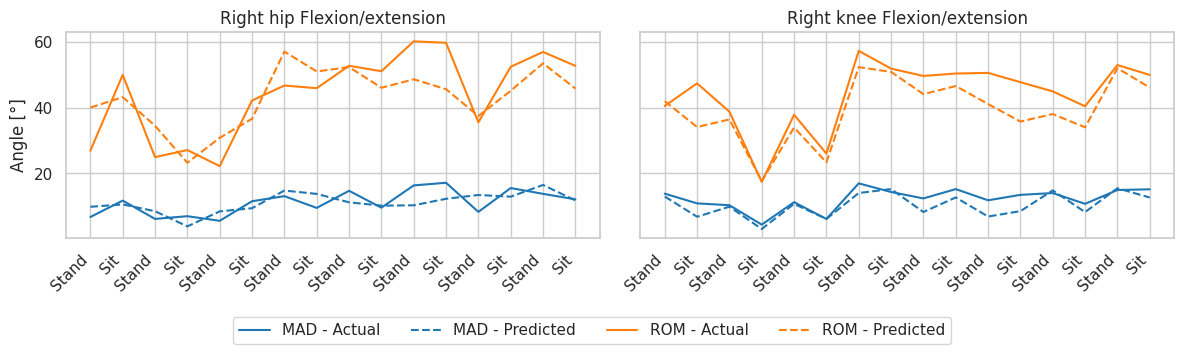

In [150]:
plot_mad_rom_combined_per_joint(
    fold_idx=1, 
    segment_range=(91, 107),  
    exercise_labels=[1,2], 
    joint_pairs={"Right hip": 3, "Right knee": 4},
    axis='y' 
)


In [140]:
import matplotlib.pyplot as plt
import numpy as np

def plot_mad_rom_scatter_by_exercise(
    fold_idx,
    segment_range,
    joint_id,
    axis='y'
):
    assert axis in ['x', 'y', 'z'], "Axis must be one of 'x', 'y', or 'z'."
    axis_idx = {'x': 0, 'z': 1, 'y': 2}[axis]

    class_labels_fold = all_actuals[fold_idx]
    pred_fold = all_preds_reg[fold_idx]
    true_fold = all_actuals_reg[fold_idx]

    exercise_labels = [1, 2]  # Sit and Stand
    label_names = {1: "Sit", 2: "Stand"}
    markers = {1: "o", 2: "s"}  # circle for sit, square for stand
    colors = {"MAD": "tab:blue", "ROM": "tab:orange"}

    sequences = []
    for label in exercise_labels:
        sequences.extend(get_label_sequences(class_labels_fold, target_label=label))
    sequences.sort()
    selected_sequences = sequences[segment_range[0]:segment_range[1]]

    joint_pred = pred_fold[:, joint_id, axis_idx]
    joint_true = true_fold[:, joint_id, axis_idx]

    mad_points = []
    rom_points = []

    for start, end in selected_sequences:
        label = int(np.bincount(class_labels_fold[start:end + 1]).argmax())

        true_seg = joint_true[start:end + 1]
        pred_seg = joint_pred[start:end + 1]

        mad_true = np.mean(np.abs(true_seg - np.mean(true_seg)))
        mad_pred = np.mean(np.abs(pred_seg - np.mean(pred_seg)))
        rom_true = np.max(true_seg) - np.min(true_seg)
        rom_pred = np.max(pred_seg) - np.min(pred_seg)

        mad_points.append((mad_true, mad_pred, label))
        rom_points.append((rom_true, rom_pred, label))

    # Plot
    fig, ax = plt.subplots(1, 1, figsize=(7, 6))

    for label in exercise_labels:
        mad_x = [m[0] for m in mad_points if m[2] == label]
        mad_y = [m[1] for m in mad_points if m[2] == label]
        rom_x = [r[0] for r in rom_points if r[2] == label]
        rom_y = [r[1] for r in rom_points if r[2] == label]

        ax.scatter(mad_x, mad_y, color=colors["MAD"], label=f"MAD - {label_names[label]}", marker=markers[label])
        ax.scatter(rom_x, rom_y, color=colors["ROM"], label=f"ROM - {label_names[label]}", marker=markers[label])

    ax.plot([0, max(ax.get_xlim()[1], ax.get_ylim()[1])], [0, max(ax.get_xlim()[1], ax.get_ylim()[1])], 'k--', lw=1)
    ax.set_xlabel("Actual [°]")
    ax.set_ylabel("Predicted [°]")
    ax.set_title(f"MAD and ROM: Actual vs Predicted (Joint {joint_id}, Axis {axis.upper()})")
    ax.grid(True)
    ax.legend(loc="upper left")

    plt.tight_layout()
    plt.show()


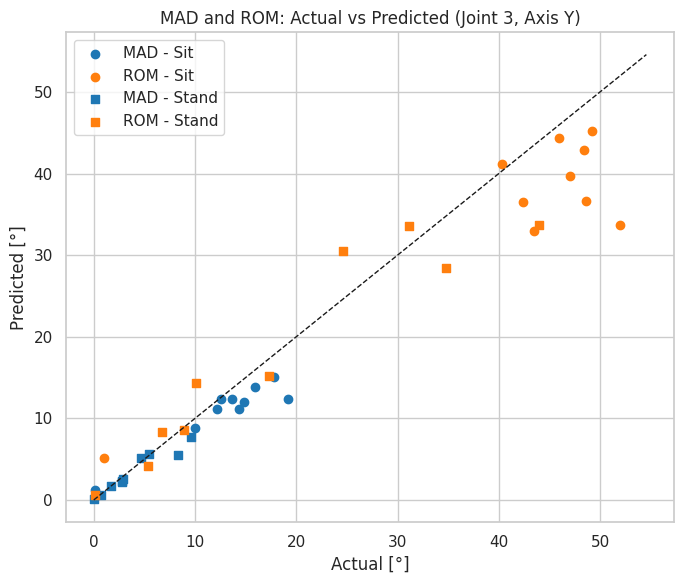

In [141]:
plot_mad_rom_scatter_by_exercise(
    fold_idx=6,
    segment_range=(0, 20),
    joint_id=3,  # for example: left hip
    axis='y'     # flexion/extension
)